In [12]:
# !pip install numpy==1.26.0  ## We use this only if there is a clash of numpy versions

In [1]:
# Import base python packages
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Avoid lal import warning
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# Import GWSignal packagess
import lalsimulation.gwsignal.core.waveform as wfm

# Import astropy units
import astropy.units as u

# Generator wrapper valid both for LAL and external approximants
from lalsimulation.gwsignal import gwsignal_get_waveform_generator

import astropy.units as u
from lalsimulation.gwsignal import (
    GenerateFDWaveform,
    GenerateTDModes,
    GenerateTDWaveform,
)
from lalsimulation.gwsignal.models import gwsignal_get_waveform_generator


No version information file '.version' found


# Generate IMREsigmaHM

In [14]:
# start with the usual parameter definitions
m1 = 40.*u.solMass
m2 = 20.*u.solMass
s1x = 0.0*u.dimensionless_unscaled # EsigmaHM does not supports precessing spins.
s1y = 0.*u.dimensionless_unscaled
s1z = 0.3*u.dimensionless_unscaled
s2x = 0.*u.dimensionless_unscaled
s2y = 0.0*u.dimensionless_unscaled
s2z = 0.5*u.dimensionless_unscaled

deltaT = 1./4096.*u.s
f_min = 20.*u.Hz  # esigmapy now supports f_ref != f_low/f_min cases.
f_ref = 22.*u.Hz
distance = 410.*u.Mpc
inclination = np.pi/3.*u.rad

phiRef = 1.3*u.rad
eccentricity = 0.3*u.dimensionless_unscaled
longAscNodes = 0.*u.rad
meanPerAno = 30.*u.rad

## EsigmaHM specific arguments

modes_to_use = [(2,2),(3,3),(4,4),(2,1),(3,2),(4,3)] # currently IMREsigmaHM supports only these modes
mode_to_align_by=(2, 2)
include_conjugate_modes=True
f_mr_transition=None
f_window_mr_transition=None
num_hyb_orbits=0.25
blend_using_avg_orbital_frequency=True
blend_aligning_merger_to_inspiral=True
keep_f_mr_transition_at_center=False
merger_ringdown_approximant="NRSur7dq4" # another choice is SEOBNRv4PHM
return_hybridization_info=False
return_orbital_params=False
failsafe=True
verbose=True
condition=1 # 0 means no tapering

python_dict = {'mass1' : m1,
              'mass2' : m2,
              'spin1x' : s1x,
              'spin1y' : s1y,
              'spin1z' : s1z,
              'spin2x' : s2x,
              'spin2y' : s2y,
              'spin2z' : s2z,
              'deltaT' : deltaT,
              'f22_start' : f_min,
              'f22_ref': f_ref,
              'phi_ref' : phiRef,
              'distance' : distance,
              'inclination' : inclination,
              'eccentricity' : eccentricity,
              'longAscNodes' : longAscNodes,
              'meanPerAno' : meanPerAno,
              'modes_to_use' : modes_to_use,
              'mode_to_align_by' : mode_to_align_by,
              'include_conjugate_modes' : include_conjugate_modes,
              'f_mr_transition' : f_mr_transition, 
              'f_window_mr_transition' : f_window_mr_transition, 
              'num_hyb_orbits' : num_hyb_orbits,
              'blend_using_avg_orbital_frequency' : blend_using_avg_orbital_frequency,
              'blend_aligning_merger_to_inspiral' : blend_aligning_merger_to_inspiral,
              'keep_f_mr_transition_at_center' : keep_f_mr_transition_at_center,
              'merger_ringdown_approximant' : merger_ringdown_approximant, 
              'return_hybridization_info' : return_hybridization_info,
              'return_orbital_params' : return_orbital_params,
              'failsafe' : failsafe,
              'verbose' : verbose,
              'condition': condition} 
"""
Please note, only `GenerateTDWaveform` i.e. polarizatrions support conditioning for the time being. 
`GenerateTDModes` does not.
"""

'\nPlease note, only `GenerateTDWaveform` i.e. polarizatrions support conditioning for the time being. \n`GenerateTDModes` does not.\n'

In [15]:
gen = gwsignal_get_waveform_generator('IMREsigmaHM')

## Generate spherical harmonic modes

Orbital evolution took: 0.02864924998721108 seconds
Modes generation took: 0.16385370801435784 seconds
Generating MR waveform from 43.673430763679114Hz...
Hybridizing the following modes: [(2, 2), (3, 3), (4, 4), (2, 1), (3, 2), (4, 3), (2, -2), (3, -3), (4, -4), (2, -1), (3, -2), (4, -3)]
By aligning (2, 2) mode
..and inheriting the phase/time shifts for alignment of [(3, 3), (4, 4), (2, 1), (3, 2), (4, 3), (2, -2), (3, -3), (4, -4), (2, -1), (3, -2), (4, -3), (2, 2)] modes
INSPIRAL mode (2, 2) goes from 11.894802857100906Hz to 116.20128139336894Hz
MERGER mode (2, 2) goes from 43.69418856865704Hz to 397.43536160719225Hz
INSPIRAL mode (3, 3) goes from 16.47597279786861Hz to 186.73081154257798Hz
MERGER mode (3, 3) goes from 65.60321549020628Hz to 624.6697991182969Hz
INSPIRAL mode (4, 4) goes from 21.79168433536524Hz to 281.1056187529836Hz
MERGER mode (4, 4) goes from -1426.4937630409843Hz to 1480.130152000572Hz
INSPIRAL mode (2, 1) goes from 5.5915602689843915Hz to 41.50085615914679Hz
M

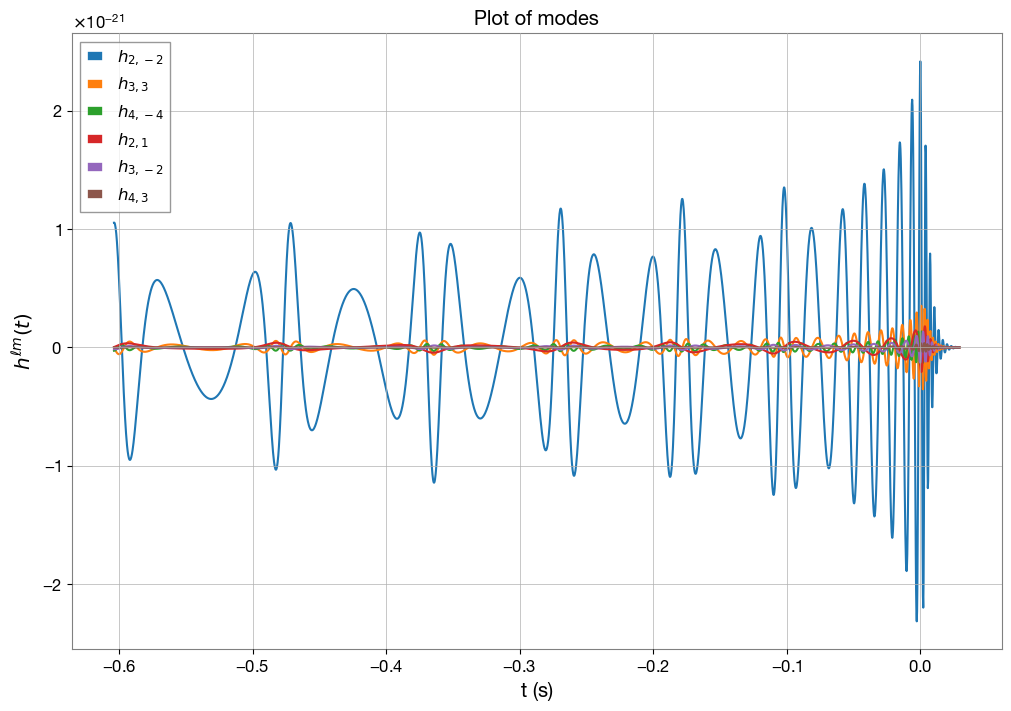

In [16]:
hlm = wfm.GenerateTDModes(python_dict, gen)
plt.figure(figsize=(12,8))
plt.plot(hlm[(2,-2)] , label=r'$h_{2,-2}$')
plt.plot(hlm[(3,3)] , label=r'$h_{3,3}$')
plt.plot(hlm[(4,-4)] , label=r'$h_{4,-4}$')
plt.plot(hlm[(2,1)] , label=r'$h_{2,1}$')
plt.plot(hlm[(3,-2)] , label=r'$h_{3,-2}$')
plt.plot(hlm[(4,3)] , label=r'$h_{4,3}$')
plt.xlabel(r't (s)')
plt.ylabel(r'$h^{\ell m}(t)$')
plt.title(r'Plot of modes')
plt.legend(loc='best');

## Generate polarizations

In [17]:
# Method 1
gwf_1 = hlm(inclination, np.pi/2*u.rad - phiRef)

In [18]:
# Method 2
hp2, hc2 = wfm.GenerateTDWaveform(python_dict, gen)

Orbital evolution took: 0.028725082986056805 seconds
Modes generation took: 0.1648453329980839 seconds
Generating MR waveform from 43.673430763679114Hz...
Hybridizing the following modes: [(2, 2), (3, 3), (4, 4), (2, 1), (3, 2), (4, 3), (2, -2), (3, -3), (4, -4), (2, -1), (3, -2), (4, -3)]
By aligning (2, 2) mode
..and inheriting the phase/time shifts for alignment of [(3, 3), (4, 4), (2, 1), (3, 2), (4, 3), (2, -2), (3, -3), (4, -4), (2, -1), (3, -2), (4, -3), (2, 2)] modes
INSPIRAL mode (2, 2) goes from 11.894802857100906Hz to 116.20128139336894Hz
MERGER mode (2, 2) goes from 43.69418856865704Hz to 397.43536160719225Hz
INSPIRAL mode (3, 3) goes from 16.47597279786861Hz to 186.73081154257798Hz
MERGER mode (3, 3) goes from 65.60321549020628Hz to 624.6697991182969Hz
INSPIRAL mode (4, 4) goes from 21.79168433536524Hz to 281.1056187529836Hz
MERGER mode (4, 4) goes from -1426.4937630409843Hz to 1480.130152000572Hz
INSPIRAL mode (2, 1) goes from 5.5915602689843915Hz to 41.50085615914679Hz
M

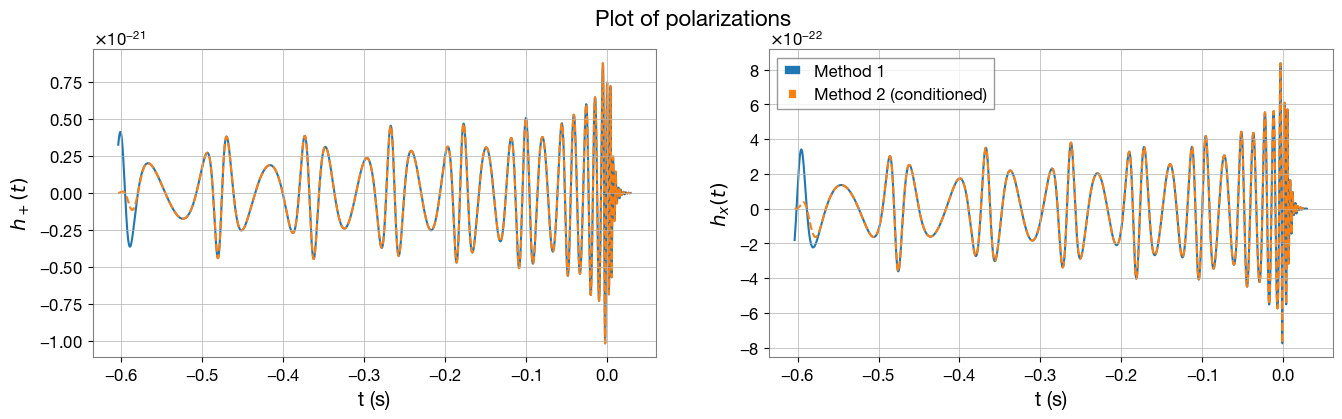

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))

ax1.plot(gwf_1.hp)
ax1.plot(hp2, '--')

ax2.plot(gwf_1.hc, label=r'Method 1')
ax2.plot(hc2, '--', label=r'Method 2 (conditioned)')

ax1.set_xlabel(r't (s)')
ax1.set_ylabel(r'$h_+(t)$')
ax2.set_xlabel(r't (s)')
ax2.set_ylabel(r'$h_x(t)$')
ax2.legend(loc='best')
fig.suptitle(r'Plot of polarizations', fontsize=16);

# Generate InspiralEsigmaHM

In [20]:
# start with the usual parameter definitions
m1 = 15.*u.solMass
m2 = 13.*u.solMass
s1x = 0.0*u.dimensionless_unscaled
s1y = 0.*u.dimensionless_unscaled
s1z = 0.3*u.dimensionless_unscaled
s2x = 0.*u.dimensionless_unscaled
s2y = 0.0*u.dimensionless_unscaled
s2z = 0.5*u.dimensionless_unscaled

deltaT = 1./4096.*u.s
f_min = 20.*u.Hz
f_ref = 22.*u.Hz
distance = 410.*u.Mpc
inclination = np.pi/3.*u.rad

phiRef = 1.3*u.rad
eccentricity = 0.3*u.dimensionless_unscaled
longAscNodes = 0.*u.rad
meanPerAno = 30.*u.rad

## EsigmaHM specific arguments

modes_to_use = [(2,2),(3,3),(4,4),(2,1),(3,2),(4,3)]
include_conjugate_modes = True
condition=1 # 0 means no tapering
return_orbital_params = False # keep this False. If you want 
                              #orbital params then use 
                              #get_inspiral_esigma_waveform 
                              #function of esigmapy.
    
python_dict = {'mass1' : m1,
              'mass2' : m2,
              'spin1x' : s1x,
              'spin1y' : s1y,
              'spin1z' : s1z,
              'spin2x' : s2x,
              'spin2y' : s2y,
              'spin2z' : s2z,
              'deltaT' : deltaT,
              'f22_start' : f_min,
              'f22_ref': f_ref,
              'phi_ref' : phiRef,
              'distance' : distance,
              'inclination' : inclination,
              'eccentricity' : eccentricity,
              'longAscNodes' : longAscNodes,
              'meanPerAno' : meanPerAno,
              'modes_to_use' : modes_to_use,
              'include_conjugate_modes' : include_conjugate_modes,
              'condition': condition} 
"""
Please note, only `GenerateTDWaveform` i.e. polarizatrions support conditioning for the time being. 
`GenerateTDModes` does not.
"""

'\nPlease note, only `GenerateTDWaveform` i.e. polarizatrions support conditioning for the time being. \n`GenerateTDModes` does not.\n'

In [21]:
gen = gwsignal_get_waveform_generator('InspiralEsigmaHM')

## Generate spherical harmonic modes

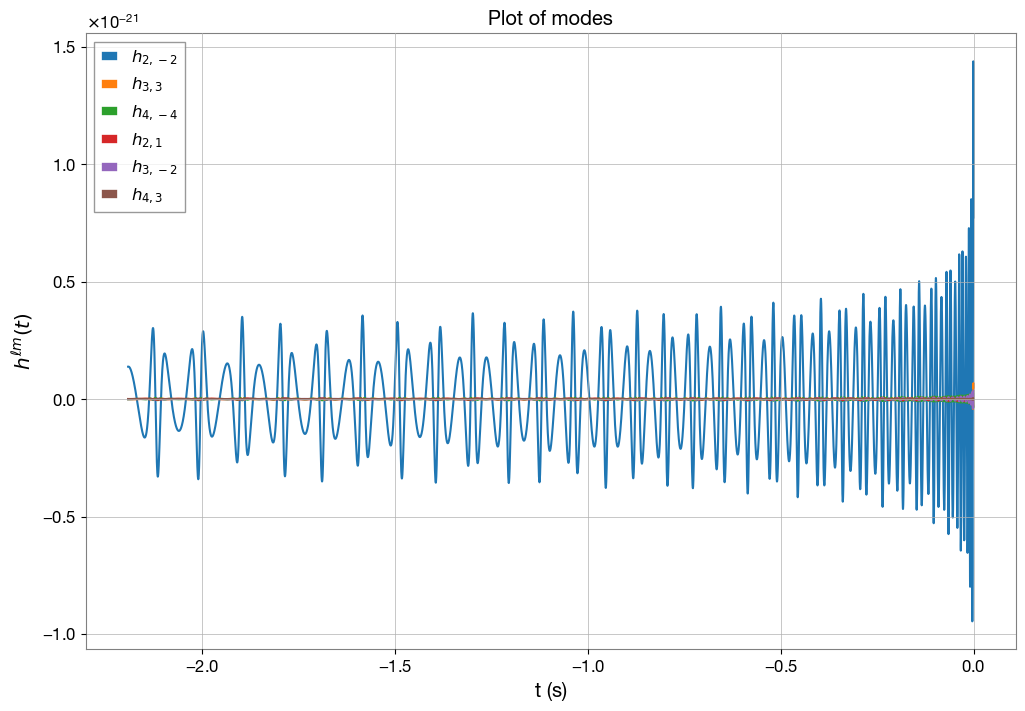

In [22]:
hlm = wfm.GenerateTDModes(python_dict, gen)
plt.figure(figsize=(12,8))
plt.plot(hlm[(2,-2)] , label=r'$h_{2,-2}$')
plt.plot(hlm[(3,3)] , label=r'$h_{3,3}$')
plt.plot(hlm[(4,-4)] , label=r'$h_{4,-4}$')
plt.plot(hlm[(2,1)] , label=r'$h_{2,1}$')
plt.plot(hlm[(3,-2)] , label=r'$h_{3,-2}$')
plt.plot(hlm[(4,3)] , label=r'$h_{4,3}$')
plt.xlabel(r't (s)')
plt.ylabel(r'$h^{\ell m} (t)$')
plt.title(r'Plot of modes')
plt.legend(loc='best');

## Generate polarizations

In [23]:
# Method 1
gwf_1 = hlm(inclination, np.pi/2*u.rad - phiRef)

In [24]:
# Method 2
hp2, hc2 = wfm.GenerateTDWaveform(python_dict, gen)

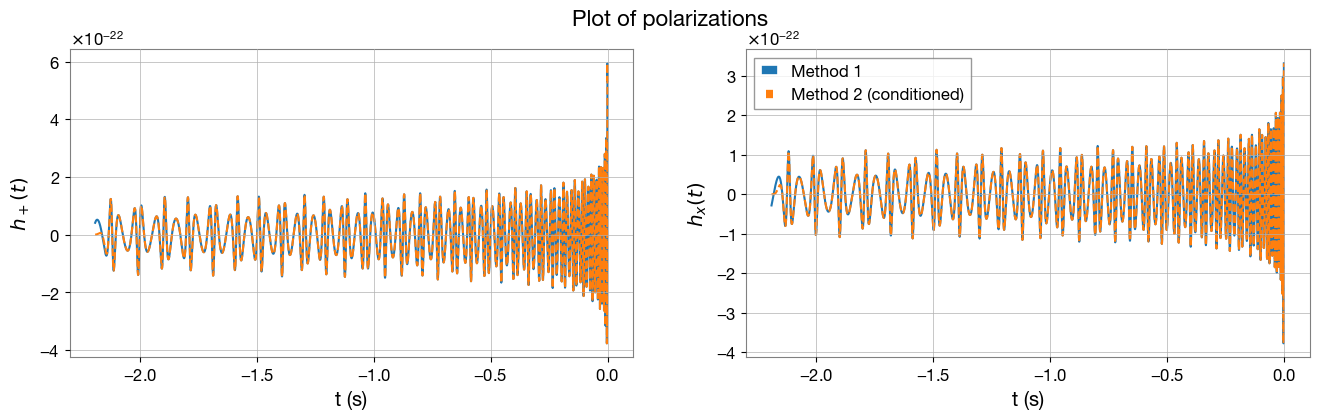

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))

ax1.plot(gwf_1.hp)
ax1.plot(hp2, '--')

ax2.plot(gwf_1.hc, label=r'Method 1')
ax2.plot(hc2, '--', label=r'Method 2 (conditioned)')

ax1.set_xlabel(r't (s)')
ax1.set_ylabel(r'$h_+(t)$')
ax2.set_xlabel(r't (s)')
ax2.set_ylabel(r'$h_x(t)$')
ax2.legend(loc='best')
fig.suptitle(r'Plot of polarizations', fontsize=16);

### End of the notebook